This notebook fits a rolling 2-state Gaussian Hidden Markov Model (HMM) on daily Bitcoin data to classify each day as either a high-volatility regime (1) or low-volatility regime (0). The output hmm_regime column and associated probability/lag features are passed downstream to Phase 2 (EGARCH/SVR-L) as additional input features.

### Methodology
Following Hashish et al. (2019), used a 2-state Gaussian HMM with full covariance matrices, estimated via the Baum-Welch algorithm and decoded via the Viterbi algorithm.

**Features fed into HMM: log_return, RV_1, RV_7, RV_30**
All features are standardised per window via StandardScaler to prevent any single feature dominating.

**Rolling window:**
- 365 days (1 year), sliding forward 1 day at a time
- HMM is refit from scratch each window. First 365 rows are not regime labeled (labeled -1) and are excluded from Phase 2.
- State relabeling: After each fit, states are relabeled consistently by comparing mean realized_volatility per state, where the higher-vol state is assigned label 1.

### Regime Labelling Results (labeled period: 2017-03-01 to 2026-02-01):
High vol regime (1): 1341 days
Low vol regime (0): 1919 days
No Label (-1): 365 days

**Output:**
df_hmm.csv, that includes the following new columns:
- hmm_regime — hard binary HMM regime labels (0 = low vol, 1 = high vol)
- hmm_prob_high —  probability of being in the high-vol state (by the HMM)
- hmm_regime_lag1 — regime label from the previous day
- hmm_prob_high_lag1 — high-vol probability from the previous day
- hmm_prob_high_lag2 — high-vol probability from 2 days ago
- hmm_prob_high_roll5 — 5-day rolling mean of hmm_prob_high (using days t-5 to t-1). To capture sustained regime trends and smooths day-to-day noise

The plot hmm_regimes.png shows BTC price (log scale) and realized volatility with high-vol periods shaded red. Key events correctly captured: 2017-2018 bull/bear cycle, March 2020 COVID crash, 2021 bull run, May 2022 Luna collapse, November 2022 FTX collapse.

In [69]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/df.csv", index_col=0, parse_dates=["date"])
features = ["log_return", "RV_1", "RV_7", "RV_30"]

# remove rows with missing values in features and additional column
df = df.dropna(subset=features + ["realized_volatility"]).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nFeature summary:")
print(df[features + ["realized_volatility"]].describe())

Dataset shape: (3625, 51)
Date range: 2016-03-01 00:00:00 to 2026-02-01 00:00:00

Feature summary:
        log_return         RV_1         RV_7        RV_30  realized_volatility
count  3625.000000  3625.000000  3625.000000  3625.000000          3625.000000
mean      0.001427     0.029610     0.029603     0.029607             0.029610
std       0.035791     0.022665     0.017222     0.014151             0.022665
min      -0.491226     0.002530     0.004570     0.006340             0.002530
25%      -0.012652     0.015246     0.018248     0.019765             0.015246
50%       0.001268     0.024141     0.025549     0.026336             0.024141
75%       0.016394     0.036360     0.035598     0.034982             0.036360
max       0.240606     0.302426     0.158375     0.085284             0.302426


In [70]:
train_window = 365 # 1 year of trading days
n_obs = len(df)

# pre-allocate the regime label array with -1 (unassigned)
regime_labels = np.full(n_obs, -1, dtype=int)
prob_high_labels = np.full(n_obs, np.nan)

In [71]:
''' following HMM literature (Hashish (2019)), 
    1. standardise features
    2. fit a 2-state Gaussian HMM via Baum-Welch
    3. most probable state sequence via Viterbi
    4. relabel states consistently: 1 = high vol, 0 = low vol '''

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

def fit_hmm_and_decode(window_df):
    X = window_df[features].values  # shape: (365, 4)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) # standardise features

    
    model = GaussianHMM(
        n_components=2,
        covariance_type="full", # each state has its own full covariance matrix, capture correlations between features within each regime
        n_iter=1000,
        random_state=4211
    )
    model.fit(X_scaled)
    
    # Viterbi algorithm to decode the most likely sequence of hidden states
    raw_states = model.predict(X_scaled) 
    raw_probs = model.predict_proba(X_scaled) # shape: (365,2)

    # Relabel states consistently across windows based on mean realized volatility
    rv = window_df["realized_volatility"].values
    
    mean_rv_state0 = rv[raw_states == 0].mean()
    mean_rv_state1 = rv[raw_states == 1].mean()
    
    if mean_rv_state0 > mean_rv_state1:
        states = 1 - raw_states
        prob_high = raw_probs[:, 0]  # state 0 was high vol, so flip
    else:
        states = raw_states
        prob_high = raw_probs[:, 1]  # state 1 is already high vol

    return states, model, prob_high


    

In [72]:
# Rolling window HMM

import warnings
warnings.filterwarnings("ignore")  # suppress hmmlearn convergence warnings

for t in range(train_window, n_obs):
    window = df.iloc[t - train_window : t] # Slice training window: rows [t-train_window, t)
    states, model, prob_high = fit_hmm_and_decode(window)
    regime_labels[t - 1]    = states[-1]
    prob_high_labels[t - 1] = prob_high[-1]
    
    # Progress update every 500 steps
    if (t - train_window) % 500 == 0:
        pct = 100 * (t - train_window) / (n_obs - train_window)
        print(f"  {t - train_window}/{n_obs - train_window} windows ({pct:.1f}%)")

print("Rolling HMM completed.")

  0/3260 windows (0.0%)
  500/3260 windows (15.3%)
  1000/3260 windows (30.7%)
  1500/3260 windows (46.0%)
  2000/3260 windows (61.3%)
  2500/3260 windows (76.7%)
  3000/3260 windows (92.0%)
Rolling HMM completed.


In [76]:
# regime labelling
df["hmm_regime"] = regime_labels
df["hmm_prob_high"] = prob_high_labels

df["hmm_regime"] = df["hmm_regime"].astype("Int64")
# summary counts
labeled    = df[df["hmm_regime"] != -1]
n_labeled  = len(labeled)
n_high     = (labeled["hmm_regime"] == 1).sum()
n_low      = (labeled["hmm_regime"] == 0).sum()
n_nolabel  = (df["hmm_regime"] == -1).sum()

print(f"High vol regime (1): {n_high}")
print(f"Low vol  regime (0): {n_low}")
print(f"No Label (-1): {n_nolabel}")

# clean for modelling
df["hmm_regime"] = df["hmm_regime"].replace(-1, np.nan)

# lag features — shift(1) ensures no look-ahead bias
df["hmm_regime_lag1"]     = df["hmm_regime"].shift(1)
df["hmm_prob_high_lag1"]  = df["hmm_prob_high"].shift(1)
df["hmm_prob_high_lag2"]  = df["hmm_prob_high"].shift(2)
df["hmm_prob_high_roll5"] = df["hmm_prob_high"].shift(1).rolling(5, min_periods=5).mean()

High vol regime (1): 1341
Low vol  regime (0): 1919
No Label (-1): 365


In [77]:
df.to_csv("df_hmm.csv", index=False)
print(df[["date", "hmm_regime", "hmm_prob_high", "hmm_regime_lag1", 
          "hmm_prob_high_lag1", "hmm_prob_high_lag2", "hmm_prob_high_roll5"]].tail(10))

           date  hmm_regime  hmm_prob_high  hmm_regime_lag1  \
3615 2026-01-23           0       0.000007                0   
3616 2026-01-24           0       0.000694                0   
3617 2026-01-25           0       0.000010                0   
3618 2026-01-26           0       0.000008                0   
3619 2026-01-27           0       0.000013                0   
3620 2026-01-28           0       0.000007                0   
3621 2026-01-29           0       0.084702                0   
3622 2026-01-30           0       0.000144                0   
3623 2026-01-31           0       0.019722                0   
3624 2026-02-01        <NA>            NaN                0   

      hmm_prob_high_lag1  hmm_prob_high_lag2  hmm_prob_high_roll5  
3615            0.000007            0.001245             0.000463  
3616            0.000007            0.000007             0.000444  
3617            0.000694            0.000007             0.000571  
3618            0.000010          

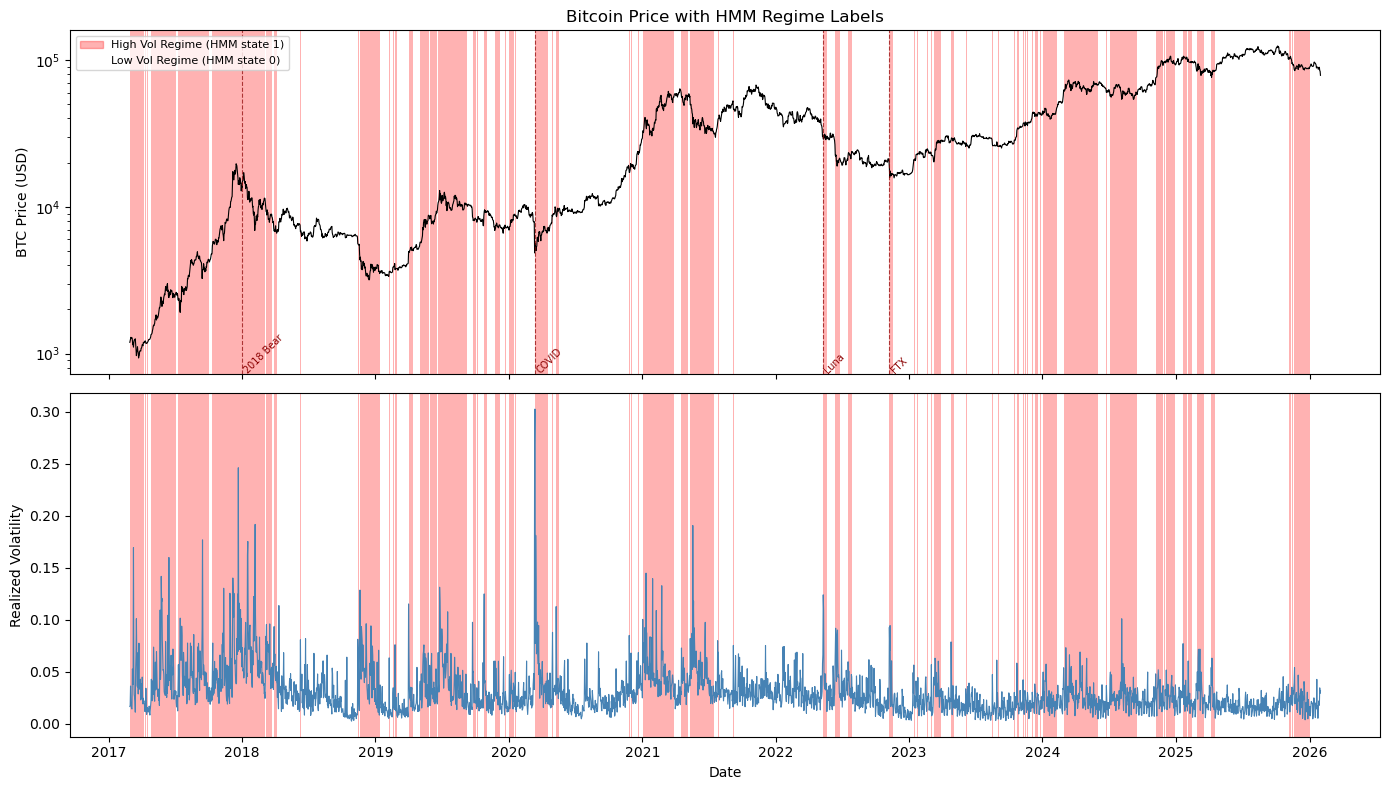

In [78]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Plot BTC price with regime shading

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
plot_df = df[df["hmm_regime"] != -1].copy()
ax1.plot(plot_df["date"], plot_df["close"], color="black", linewidth=0.8, label="BTC Close")
ax1.set_ylabel("BTC Price (USD)")
ax1.set_title("Bitcoin Price with HMM Regime Labels")
ax1.set_yscale("log")  # log scale makes the full 2017-2026 range readable

ax2.plot(plot_df["date"], plot_df["realized_volatility"], color="steelblue", linewidth=0.8)
ax2.set_ylabel("Realized Volatility")
ax2.set_xlabel("Date")

# Shade high vol regime (state 1) on both panels
in_high_vol = False
start_date = None

for _, row in plot_df.iterrows():
    if row["hmm_regime"] == 1 and not in_high_vol:
        # entering high vol regime
        in_high_vol = True
        start_date = row["date"]
    elif row["hmm_regime"] == 0 and in_high_vol:
        # exiting high vol regime
        in_high_vol = False
        ax1.axvspan(start_date, row["date"], alpha=0.3, color="red", linewidth=0)
        ax2.axvspan(start_date, row["date"], alpha=0.3, color="red", linewidth=0)

# Handle case where series ends in high vol regime
if in_high_vol:
    ax1.axvspan(start_date, plot_df["date"].iloc[-1], alpha=0.3, color="red", linewidth=0)
    ax2.axvspan(start_date, plot_df["date"].iloc[-1], alpha=0.3, color="red", linewidth=0)

# Annotate known structural breaks
events = {
    "2018 Bear": "2018-01-01",
    "COVID":     "2020-03-12",
    "Luna":      "2022-05-09",
    "FTX":       "2022-11-08"
}
for label, date in events.items():
    ax1.axvline(pd.Timestamp(date), color="darkred", linestyle="--", linewidth=0.8, alpha=0.7)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[0], label, fontsize=7, color="darkred", rotation=45)

high_patch = mpatches.Patch(color="red", alpha=0.3, label="High Vol Regime (HMM state 1)")
low_patch  = mpatches.Patch(color="white", edgecolor="grey", label="Low Vol Regime (HMM state 0)")
ax1.legend(handles=[high_patch, low_patch], loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("hmm_regimes.png", dpi=150, bbox_inches="tight")
plt.show()